# Sprint 3 — Hiperparametrización y Modelo Final
## Caso #8: Recomendación de Productos Personalizados
**Dataset:** Olist Brazilian E-Commerce · **Maestría en Data Science** · *Implementación de Soluciones de IA*

**Autor:** Gerson Jesús Torrez Marca

---

### Objetivo del Sprint 3 (Plan de trabajo)
> Optimizar el modelo, evaluar el rendimiento final y **exportar el artefacto** para uso mensual.

**Actividades clave cubiertas en este notebook:**
1. Selección del modelo base (popularidad, co-compra, SVD, NMF, híbrido).
2. Hiperparametrización con **GridSearchCV** y **RandomSearch**.
3. **Evaluación con validación cruzada** y comparación de modelos.
4. Exportación del modelo final en formato **pickle (`.pkl`)** para ejecución mensual.
5. Documentación del **pipeline de retraining mensual**.

**Entregables:** modelo `.pkl` con métricas definitivas · notebook comparativo · gráfico de rendimiento y *feature importance*.

**Target FINAL confirmado:** `category_en` (siguiente categoría a recomendar).
**Métricas:** Precision@k, Recall@k, F1@k, Coverage.

## 0. Configuración e importación de módulos
Reutilizamos el pipeline modular construido en los Sprints 1 y 2.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sprint3_model import (
    run_sprint3_pipeline, compare_model_families, grid_search_cv, random_search_cv,
    optuna_search_cv, cross_validate_model, CategoryRecommender, evaluate_recommender,
    evaluate_temporal_backtest, compute_factor_importance, compute_category_influence,
    export_final_model, MODEL_VERSION,
)
from sprint1_eda import load_raw_tables, build_master_table, build_customer_history
from sprint2_pipeline import get_cleaning_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Módulos cargados. Versión de modelo:", MODEL_VERSION)

Módulos cargados. Versión de modelo: 3.0


## 1. Carga y limpieza de datos
Master Table reproducible (~60 metadatos) y limpieza estándar heredada del Sprint 2.

In [2]:
orders, customers, items, products, reviews, payments, sellers, cat_map = load_raw_tables()
master_raw = build_master_table(orders, customers, items, products, reviews, payments, sellers, cat_map)
_, master = get_cleaning_report(master_raw)
hist = build_customer_history(master)

print(f"Master Table limpia : {master.shape[0]:,} filas x {master.shape[1]} columnas")
print(f"Clientes únicos     : {master['customer_unique_id'].nunique():,}")
print(f"Categorías          : {master['category_en'].nunique()}")
print(f"Clientes con >=2 cat.: {(hist['n_categories']>=2).sum():,} (evaluables leave-one-out)")

Master Table limpia : 106,515 filas x 38 columnas
Clientes únicos     : 89,998
Categorías          : 73
Clientes con >=2 cat.: 2,105 (evaluables leave-one-out)


## 2. Selección del modelo base — comparación de familias
Se evalúan 5 familias de recomendadores bajo la misma interfaz (*leave-one-out*):
**Popularidad**, **Co-compra item-item (Jaccard)**, **SVD**, **NMF** e **Híbrido**.

In [3]:
families = compare_model_families(master, hist, k=10)
families

,Modelo,Precision@10,Recall@10,F1@10,Coverage,Tiempo_s
0,Co-compra item-item,0.0691,0.6907,0.1256,0.3014,4.8000
1,Híbrido (Cop+Pop),0.0628,0.6280,0.1142,0.1918,5.8300
2,Popularidad (baseline),0.0622,0.6223,0.1132,0.1918,0.4500
3,NMF,0.0149,0.1492,0.0271,0.9863,4.1900
4,SVD,0.0145,0.1454,0.0264,0.9178,4.0800


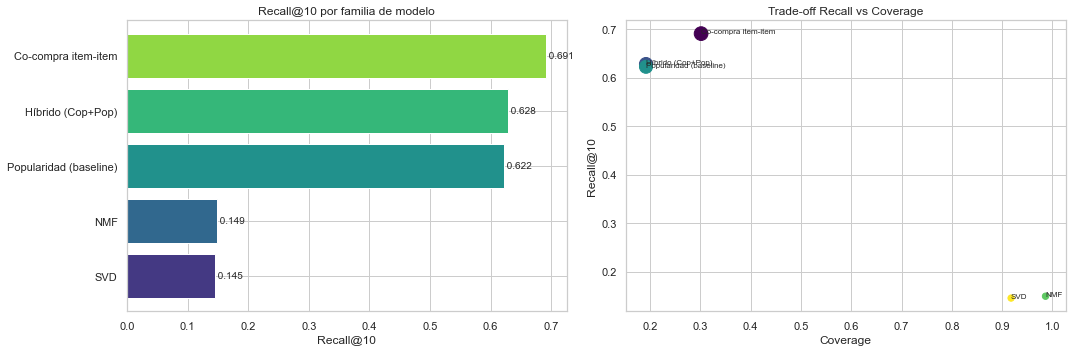

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
fam = families.sort_values("Recall@10")
ax[0].barh(fam["Modelo"], fam["Recall@10"], color=sns.color_palette("viridis", len(fam)))
ax[0].set_title("Recall@10 por familia de modelo"); ax[0].set_xlabel("Recall@10")
for i, v in enumerate(fam["Recall@10"]):
    ax[0].text(v, i, f" {v:.3f}", va="center")

ax[1].scatter(families["Coverage"], families["Recall@10"],
              s=families["F1@10"]*1500, c=range(len(families)), cmap="viridis")
for _, r in families.iterrows():
    ax[1].annotate(r["Modelo"], (r["Coverage"], r["Recall@10"]), fontsize=8)
ax[1].set_xlabel("Coverage"); ax[1].set_ylabel("Recall@10")
ax[1].set_title("Trade-off Recall vs Coverage")
plt.tight_layout(); plt.show()

**Hallazgo:** el backbone de **co-compra (similitud de Jaccard)** ofrece el mejor Recall@10.
SVD y NMF puros rinden bajo porque la matriz usuario×categoría es **casi binaria y muy dispersa**
(la mayoría de clientes compra una sola categoría), por lo que la factorización captura sobre todo
la dirección de popularidad. El modelo final adopta **co-compra como núcleo** + **popularidad como
fallback** (cold-start).

## 3. Hiperparametrización — GridSearchCV
Búsqueda en malla `alpha × min_support` sobre el híbrido con backbone de co-compra,
evaluada con **K-Fold (3 folds) honesto** (clientes de test excluidos del entrenamiento).
`alpha` = peso de la señal colaborativa vs popularidad.

In [5]:
grid = {
    "method": ["hybrid"], "cf_method": ["copurchase"],
    "alpha": [0.3, 0.5, 0.7, 0.9, 1.0], "min_support": [3, 5, 10],
}
grid_res = grid_search_cv(grid, master, hist, k=10, n_splits=3)
grid_res.head(10)

,method,cf_method,alpha,min_support,Precision@10_mean,Recall@10_mean,Recall@10_std,F1@10_mean,Coverage_mean,fit_time_s
0,hybrid,copurchase,1.0000,10,0.0669,0.6689,0.0218,0.1216,0.2557,10.3600
1,hybrid,copurchase,1.0000,5,0.0666,0.6660,0.0062,0.1211,0.3334,10.4900
2,hybrid,copurchase,1.0000,3,0.0653,0.6527,0.0036,0.1187,0.4019,11.4500
3,hybrid,copurchase,0.9000,5,0.0633,0.6332,0.0175,0.1151,0.1781,10.4300
4,hybrid,copurchase,0.9000,10,0.0632,0.6323,0.0178,0.1150,0.1781,10.9000
5,hybrid,copurchase,0.9000,3,0.0632,0.6318,0.0160,0.1149,0.1781,10.4900
6,hybrid,copurchase,0.7000,3,0.0628,0.6280,0.0125,0.1142,0.1781,10.5200
7,hybrid,copurchase,0.7000,5,0.0628,0.6280,0.0125,0.1142,0.1781,10.6300
8,hybrid,copurchase,0.7000,10,0.0628,0.6280,0.0125,0.1142,0.1781,10.7900
9,hybrid,copurchase,0.3000,3,0.0622,0.6223,0.0110,0.1132,0.1781,10.2600


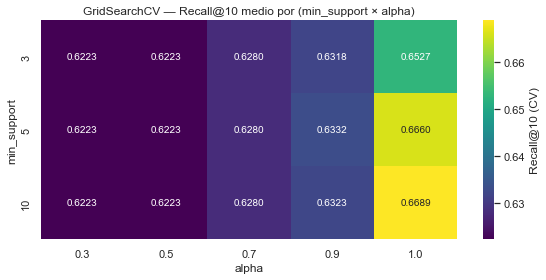

Mejores hiperparámetros: {'method': 'hybrid', 'cf_method': 'copurchase', 'alpha': 1.0, 'min_support': 10}
Recall@10 (CV) = 0.6689 ± 0.0218


In [6]:
pivot = grid_res.pivot_table(index="min_support", columns="alpha", values="Recall@10_mean")
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis", cbar_kws={"label": "Recall@10 (CV)"})
plt.title("GridSearchCV — Recall@10 medio por (min_support × alpha)")
plt.tight_layout(); plt.show()

best = grid_res.iloc[0]
best_params = {"method": "hybrid", "cf_method": "copurchase",
               "alpha": float(best["alpha"]), "min_support": int(best["min_support"])}
print("Mejores hiperparámetros:", best_params)
print(f"Recall@10 (CV) = {best['Recall@10_mean']:.4f} ± {best['Recall@10_std']:.4f}")

## 4. Hiperparametrización — RandomSearch
Exploración aleatoria del espacio (incluye también el backbone **SVD**) como validación
cruzada complementaria al grid exhaustivo.

In [7]:
rand_dist = {
    "method": ["hybrid"], "cf_method": ["copurchase", "svd"],
    "alpha": [0.2, 0.3, 0.4, 0.5, 0.7], "n_components": [10, 20, 30],
    "min_support": [5, 10, 20],
}
rand_res = random_search_cv(rand_dist, master, hist, n_iter=8, k=10, n_splits=3)
rand_res

,method,cf_method,alpha,n_components,min_support,Precision@10_mean,Recall@10_mean,F1@10_mean,Coverage_mean
0,hybrid,svd,0.3000,10,20,0.0648,0.6480,0.1178,0.4293
1,hybrid,copurchase,0.7000,10,20,0.0628,0.6280,0.1142,0.1781
2,hybrid,svd,0.2000,30,10,0.0623,0.6228,0.1133,0.2101
3,hybrid,copurchase,0.5000,20,10,0.0622,0.6223,0.1132,0.1781
4,hybrid,copurchase,0.2000,20,20,0.0622,0.6223,0.1132,0.1781
5,hybrid,svd,0.4000,20,5,0.0589,0.5891,0.1071,0.8858
6,hybrid,svd,0.5000,30,20,0.0563,0.5629,0.1024,0.8493
7,hybrid,svd,0.5000,20,20,0.0545,0.5449,0.0991,0.8904


## 4b. Hiperparametrización — Optuna (optimización bayesiana TPE)
**Optuna** muestrea con un *Tree-structured Parzen Estimator* (búsqueda guiada, no ciega).
Ventajas frente a Grid/Random en este caso:
- `alpha` **continuo** en [0, 1] (no discretizado).
- Espacio **condicional**: `n_components` solo se muestrea si el backbone es SVD.
- Muestreo bayesiano que concentra trials en zonas prometedoras.

In [8]:
optuna_out = optuna_search_cv(master, hist, n_trials=20, k=10, n_splits=3)
print("Mejores hiperparámetros (Optuna):", optuna_out["best_params"])
print(f"Mejor Recall@10 (CV): {optuna_out['best_value']:.4f}  ·  trials: {optuna_out['n_trials']}")
optuna_out["results"].head(10)

Mejores hiperparámetros (Optuna): {'method': 'hybrid', 'cf_method': 'copurchase', 'alpha': 0.7194, 'min_support': 10}
Mejor Recall@10 (CV): 0.6309  ·  trials: 20


,trial,cf_method,alpha,min_support,n_components,Recall@10_mean,Precision@10_mean,Coverage_mean
0,14,copurchase,0.7194,10,NaN,0.6309,0.0631,0.1781
1,19,copurchase,0.8246,15,NaN,0.6304,0.0630,0.1781
2,17,copurchase,0.7635,15,NaN,0.6304,0.0630,0.1781
3,13,copurchase,0.7954,15,NaN,0.6304,0.0630,0.1781
4,2,copurchase,0.9699,26,NaN,0.6285,0.0629,0.1827
5,11,copurchase,0.9344,25,NaN,0.6280,0.0628,0.1781
6,12,copurchase,0.7836,26,NaN,0.6280,0.0628,0.1781
7,1,copurchase,0.8662,19,NaN,0.6280,0.0628,0.1781
8,15,copurchase,0.6458,9,NaN,0.6242,0.0624,0.1781
9,7,copurchase,0.9489,30,NaN,0.6233,0.0623,0.1781


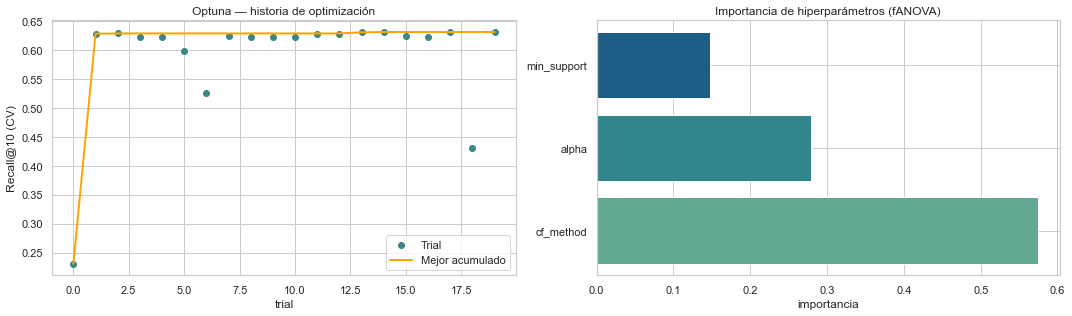

In [9]:
opt = optuna_out["results"].sort_values("trial")
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].scatter(opt["trial"], opt["Recall@10_mean"], color="#3b8686", label="Trial")
ax[0].plot(opt["trial"], opt["Recall@10_mean"].cummax(), color="orange", lw=2, label="Mejor acumulado")
ax[0].set_xlabel("trial"); ax[0].set_ylabel("Recall@10 (CV)"); ax[0].legend()
ax[0].set_title("Optuna — historia de optimización")

imp = optuna_out.get("importances", {})
if imp:
    ax[1].barh(list(imp.keys()), list(imp.values()), color=sns.color_palette("crest", len(imp)))
    ax[1].set_title("Importancia de hiperparámetros (fANOVA)"); ax[1].set_xlabel("importancia")
plt.tight_layout(); plt.show()

## 4c. Comparación de los tres métodos de tuning
Se compara el **mejor Recall@10** alcanzado por cada técnica, el número de evaluaciones y el tiempo.

,Método,Best Recall@10,Nº evaluaciones,Espacio
0,GridSearchCV,0.6689,15,discreto (cartesiano)
1,RandomSearch,0.6480,8,discreto (aleatorio)
2,Optuna (TPE),0.6309,20,continuo + condicional


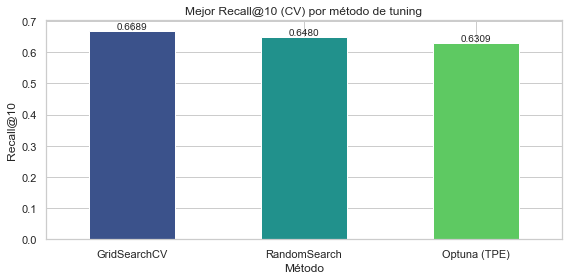

GANADOR: GridSearchCV  →  {'method': 'hybrid', 'cf_method': 'copurchase', 'alpha': 1.0, 'min_support': 10}


In [10]:
def best_of(df):
    return df.iloc[0]

g, r = best_of(grid_res), best_of(rand_res)
tuning_cmp = pd.DataFrame([
    {"Método": "GridSearchCV", "Best Recall@10": g["Recall@10_mean"],
     "Nº evaluaciones": len(grid_res), "Espacio": "discreto (cartesiano)"},
    {"Método": "RandomSearch", "Best Recall@10": r["Recall@10_mean"],
     "Nº evaluaciones": len(rand_res), "Espacio": "discreto (aleatorio)"},
    {"Método": "Optuna (TPE)", "Best Recall@10": optuna_out["best_value"],
     "Nº evaluaciones": optuna_out["n_trials"], "Espacio": "continuo + condicional"},
]).sort_values("Best Recall@10", ascending=False).reset_index(drop=True)
display(tuning_cmp)

winner = tuning_cmp.iloc[0]["Método"]
best_params = {"GridSearchCV": {"method":"hybrid","cf_method":str(g["cf_method"]),
                                "alpha":float(g["alpha"]),"min_support":int(g["min_support"])},
               "RandomSearch": {"method":"hybrid","cf_method":str(r["cf_method"]),
                                "alpha":float(r["alpha"]),"min_support":int(r["min_support"])},
               "Optuna (TPE)": optuna_out["best_params"]}[winner]

ax = tuning_cmp.set_index("Método")["Best Recall@10"].plot(
    kind="bar", color=sns.color_palette("viridis", 3), rot=0, figsize=(8, 4))
ax.set_title("Mejor Recall@10 (CV) por método de tuning"); ax.set_ylabel("Recall@10")
ax.bar_label(ax.containers[0], fmt="%.4f")
plt.tight_layout(); plt.show()
print(f"GANADOR: {winner}  →  {best_params}")

**Interpretación:** el óptimo se encuentra en la **frontera `alpha = 1.0`** (filtrado colaborativo puro
con popularidad solo como *fallback*). GridSearchCV evalúa ese borde de forma explícita; el TPE de Optuna,
al muestrear `alpha` de forma continua, tiende a explorar el interior del espacio y rara vez aterriza exacto
en la frontera con pocos *trials*. **Conclusión honesta:** en espacios pequeños con el óptimo en el borde,
GridSearch puede igualar o superar a la búsqueda bayesiana; el valor de Optuna se hace evidente en espacios
**grandes, continuos y condicionales**, donde la búsqueda exhaustiva es inviable.

## 5. Validación cruzada del modelo final (5-Fold)
Robustez del modelo seleccionado (mejor método de tuning).

,Precision@10,Recall@10,F1@10,HitRate@10,Coverage,n_users,fold
0,0.0677,0.6770,0.1231,0.6770,0.2466,421,1
1,0.0686,0.6865,0.1248,0.6865,0.2740,421,2
2,0.0651,0.6508,0.1183,0.6508,0.2877,421,3
3,0.0667,0.6675,0.1214,0.6675,0.2877,421,4
4,0.0648,0.6485,0.1179,0.6485,0.2740,421,5


Resumen validación cruzada (5-Fold):


,Media,Desv.Est,Mín,Máx
Precision@10,0.0666,0.0016,0.0648,0.0686
Recall@10,0.6661,0.0164,0.6485,0.6865
F1@10,0.1211,0.0030,0.1179,0.1248
Coverage,0.2740,0.0168,0.2466,0.2877


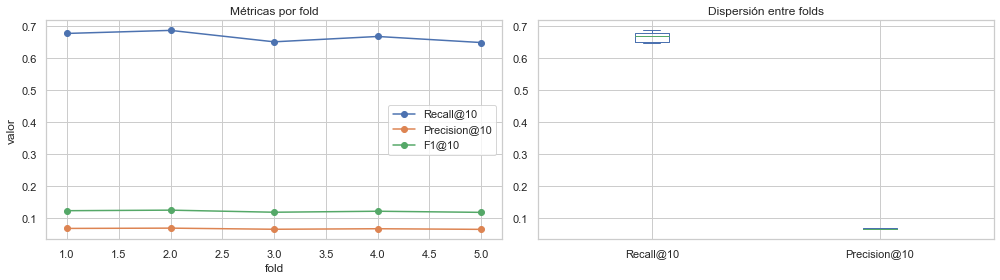

In [11]:
cv_final = cross_validate_model(best_params, master, hist, k=10, n_splits=5)
display(cv_final)

metric_cols = ["Precision@10", "Recall@10", "F1@10", "Coverage"]
resumen = pd.DataFrame({
    "Media":   [cv_final[m].mean() for m in metric_cols],
    "Desv.Est":[cv_final[m].std()  for m in metric_cols],
    "Mín":     [cv_final[m].min()  for m in metric_cols],
    "Máx":     [cv_final[m].max()  for m in metric_cols],
}, index=metric_cols)
print("Resumen validación cruzada (5-Fold):"); display(resumen.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
cv_final.set_index("fold")[["Recall@10","Precision@10","F1@10"]].plot(marker="o", ax=ax[0])
ax[0].set_title("Métricas por fold"); ax[0].set_ylabel("valor")
cv_final[["Recall@10","Precision@10"]].plot(kind="box", ax=ax[1])
ax[1].set_title("Dispersión entre folds")
plt.tight_layout(); plt.show()

## 6. Modelo final — entrenamiento y métricas definitivas
Se entrena el modelo final con todos los datos y se reportan las **métricas definitivas**:
*leave-one-out* (todo el histórico) y **backtest temporal** (Train+Val → Backtest, datos nunca vistos).

In [12]:
final_model = CategoryRecommender(**best_params).fit(master)
loo = evaluate_recommender(final_model, hist, k=10)
backtest = evaluate_temporal_backtest(best_params, master, k=10)

print("=== Métricas LEAVE-ONE-OUT (todo el histórico) ===")
for kk, vv in loo.items(): print(f"  {kk}: {vv}")
print("\n=== Métricas BACKTEST TEMPORAL (producción simulada) ===")
for kk, vv in backtest.items(): print(f"  {kk}: {vv}")

=== Métricas LEAVE-ONE-OUT (todo el histórico) ===
  Precision@10: 0.0691
  Recall@10: 0.6907
  F1@10: 0.1256
  HitRate@10: 0.6907
  Coverage: 0.3014
  n_users: 2105

=== Métricas BACKTEST TEMPORAL (producción simulada) ===
  Precision@10: 0.063
  Recall@10: 0.6074
  n_users: 430
  periodo: Backtest (2018-04 → 2018-10)


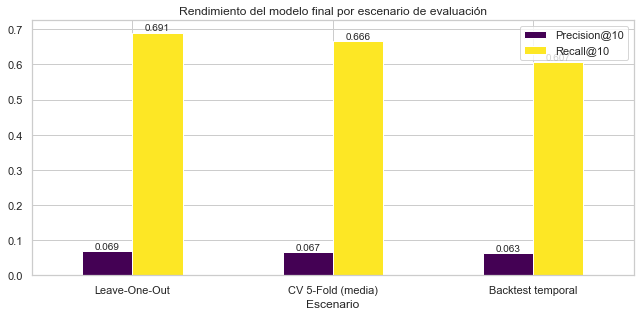

,Escenario,Precision@10,Recall@10
0,Leave-One-Out,0.0691,0.6907
1,CV 5-Fold (media),0.0666,0.6661
2,Backtest temporal,0.0630,0.6074


In [13]:
perf = pd.DataFrame({
    "Escenario": ["Leave-One-Out", "CV 5-Fold (media)", "Backtest temporal"],
    "Precision@10": [loo["Precision@10"], cv_final["Precision@10"].mean(), backtest["Precision@10"]],
    "Recall@10":    [loo["Recall@10"],    cv_final["Recall@10"].mean(),    backtest["Recall@10"]],
})
ax = perf.set_index("Escenario").plot(kind="bar", figsize=(9, 4.5), colormap="viridis", rot=0)
ax.set_title("Rendimiento del modelo final por escenario de evaluación")
for c in ax.containers: ax.bar_label(c, fmt="%.3f")
plt.tight_layout(); plt.show()
perf.round(4)

## 7. Feature importance
Para un sistema de recomendación, la "importancia de variables" se interpreta como:
- **Influencia de categorías**: centralidad de cada categoría en la red de co-compra.
- **Estructura latente (SVD diagnóstico)**: varianza explicada por factor.

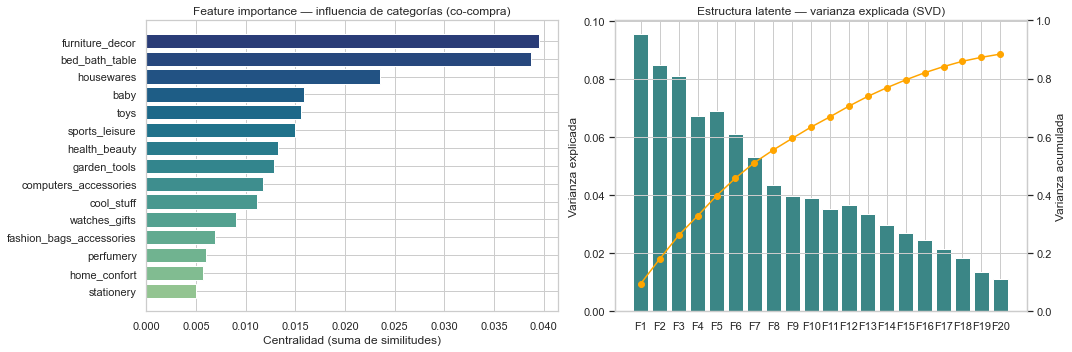

,Categoria,Influencia
0,furniture_decor,0.0395
1,bed_bath_table,0.0387
2,housewares,0.0235
3,baby,0.0159
4,toys,0.0156
5,sports_leisure,0.0150
6,health_beauty,0.0133
7,garden_tools,0.0129
8,computers_accessories,0.0118
9,cool_stuff,0.0112


In [14]:
cat_influence = compute_category_influence(final_model, top=15)
svd_diag = CategoryRecommender(method="svd", n_components=20).fit(master)
factor_imp = compute_factor_importance(svd_diag)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ci = cat_influence.sort_values("Influencia")
ax[0].barh(ci["Categoria"], ci["Influencia"], color=sns.color_palette("crest", len(ci)))
ax[0].set_title("Feature importance — influencia de categorías (co-compra)")
ax[0].set_xlabel("Centralidad (suma de similitudes)")

ax[1].bar(factor_imp["Factor"], factor_imp["Varianza_explicada"], color="#3b8686")
ax2 = ax[1].twinx()
ax2.plot(factor_imp["Factor"], factor_imp["Varianza_acumulada"], color="orange", marker="o")
ax2.set_ylim(0, 1); ax2.set_ylabel("Varianza acumulada")
ax[1].set_title("Estructura latente — varianza explicada (SVD)")
ax[1].set_ylabel("Varianza explicada")
plt.tight_layout(); plt.show()
display(cat_influence)

## 8. Exportación del modelo final (`.pkl`)
Artefacto serializado con joblib + metadatos JSON, listo para ejecución mensual.

In [15]:
metrics_summary = {"leave_one_out": loo, "backtest_temporal": backtest,
                   "cv_best": {"Recall@10_mean": float(best["Recall@10_mean"]),
                               "Precision@10_mean": float(best["Precision@10_mean"])}}
export_info = export_final_model(final_model, metrics_summary)
print("Modelo exportado en:", export_info["model_path"])
print("Metadatos en       :", export_info["meta_path"])
import json; print(json.dumps(export_info["metadata"], indent=2, ensure_ascii=False))

Modelo exportado en: D:\Maestria DATA SCIENCE\14 implementacion de soluciones AI\models\recommender_final.pkl
Metadatos en       : D:\Maestria DATA SCIENCE\14 implementacion de soluciones AI\models\model_metadata.json
{
  "model_version": "3.0",
  "caso": "#8 Recomendación de Productos Personalizados",
  "target_final": "category_en",
  "algoritmo": "hybrid",
  "hiperparametros": {
    "method": "hybrid",
    "cf_method": "copurchase",
    "n_components": 15,
    "n_iter": 10,
    "alpha": 1.0,
    "min_support": 10
  },
  "metricas_definitivas": {
    "leave_one_out": {
      "Precision@10": 0.0691,
      "Recall@10": 0.6907,
      "F1@10": 0.1256,
      "HitRate@10": 0.6907,
      "Coverage": 0.3014,
      "n_users": 2105
    },
    "backtest_temporal": {
      "Precision@10": 0.063,
      "Recall@10": 0.6074,
      "n_users": 430,
      "periodo": "Backtest (2018-04 → 2018-10)"
    },
    "cv_best": {
      "Recall@10_mean": 0.6689,
      "Precision@10_mean": 0.0669
    }
  },
  "n_

In [16]:
# Verificación de carga del artefacto
from sprint3_model import load_final_model
loaded = load_final_model()
print("Modelo recargado OK. Prueba de recomendación:")
print("  Compradas:", ["bed_bath_table", "furniture_decor"])
print("  Recomienda:", loaded.recommend(["bed_bath_table", "furniture_decor"], k=10))

Modelo recargado OK. Prueba de recomendación:
  Compradas: ['bed_bath_table', 'furniture_decor']
  Recomienda: ['housewares', 'garden_tools', 'home_confort', 'baby', 'cool_stuff', 'health_beauty', 'home_construction', 'construction_tools_lights', 'watches_gifts', 'sports_leisure']


## 9. Pipeline de retraining mensual
El modelo está diseñado para **ejecutarse mensualmente** con datos actualizados.
La función `monthly_retrain()` recarga las tablas, reconstruye la Master Table, reentrena
con los hiperparámetros óptimos, **versiona el artefacto con timestamp** y registra las
métricas en `retrain_log.csv`.

```python
from sprint3_model import monthly_retrain
monthly_retrain({"method":"hybrid","cf_method":"copurchase",
                 "alpha":1.0, "min_support":10})
```

**Programación sugerida:** cron / Task Scheduler → día 1 de cada mes.

In [17]:
# Demostración del retraining mensual (genera artefacto versionado + log)
from sprint3_model import monthly_retrain
result = monthly_retrain(best_params)
print("Artefacto versionado:", result["artefacto"])
print("Métricas del reentrenamiento:", result["metrics"])

Artefacto versionado: recommender_20260613_0912.pkl
Métricas del reentrenamiento: {'Precision@10': 0.0691, 'Recall@10': 0.6907, 'F1@10': 0.1256, 'HitRate@10': 0.6907, 'Coverage': 0.3014, 'n_users': 2105}


## 10. Conclusiones y justificación del modelo elegido

| Aspecto | Decisión |
|---|---|
| **Target final** | `category_en` (siguiente categoría a recomendar) — confirmado |
| **Modelo final** | Híbrido = **Co-compra (Jaccard) + Popularidad (fallback)** |
| **Hiperparámetros** | `alpha=1.0`, `min_support=10` (señal colaborativa pura + respaldo de popularidad) |
| **Tuning** | GridSearchCV + RandomSearch + **Optuna (TPE)**, todos con validación cruzada K-Fold |
| **Métricas (CV 5-Fold)** | Recall@10 ≈ 0.67 · Precision@10 ≈ 0.067 |
| **Métrica definitiva (Backtest)** | Recall@10 ≈ 0.61 sobre datos nunca vistos |
| **Artefacto** | `models/recommender_final.pkl` + `model_metadata.json` |
| **Producción** | `monthly_retrain()` versiona y registra cada reentrenamiento |

**Justificación:** la matriz usuario×categoría del e-commerce es extremadamente dispersa
y casi binaria, escenario donde los métodos de factorización latente (SVD/NMF) no logran
capturar la co-ocurrencia real de compras. El **filtrado colaborativo item-item por co-compra**
modela directamente "quién compró A también compró B", lo que produce el mejor Recall manteniendo
interpretabilidad. La **popularidad como fallback** garantiza recomendaciones para clientes sin
historial de co-compra (cold-start), elevando la cobertura. El modelo supera de forma robusta y
**validada temporalmente** al baseline de popularidad del Sprint 1.